# One-Month-Reversal -- a quantitative teardown
### Monthly S&P 500 quintile spread * the bid-ask-bounce test * beta-neutrality * decay * HAC inference

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Bid--ask bounce: Confirmed](https://img.shields.io/badge/Bid--ask_bounce-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). Same seven beats, every claim carrying its standard error. We test whether the Jegadeesh (1990) one-month loser-minus-winner spread survives (a) a HAC t-test, (b) a one-month-gap (skip=1) microstructure test, (c) a beta decomposition, (d) a sub-period split, and (e) realistic transaction costs -- and we plant a known reversal in a synthetic market to confirm the engine is a faithful detector.

> **Not investment advice.** Real data: shared S&P 500 monthly closes, 1990-01-31 to 2026-05-31 (as-of 2026-06-15, fingerprint `fa033b6cedf6`). Methods in [`docs/references.md`](../docs/references.md); numbers in [`docs/results.md`](../docs/results.md).
>
> **Survivorship bias**: the universe is the current S&P 500 projected backwards; all real-tape results are upper bounds.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from one_month_reversal import data, strategy as st

# Cache-first, offline-safe: try the real panel, fall back to the synthetic tape.
try:
    prices = data.load_real()
    res0 = st.quintile_returns(st.trailing_return(prices, skip=0), prices, q=0.20)
    res1 = st.quintile_returns(st.trailing_return(prices, skip=1), prices, q=0.20)
    spread = res0["spread"].dropna()
    HAVE_REAL = True
    print(f"REAL tape loaded: {prices.shape[0]} months x {prices.shape[1]} tickers "
          f"({prices.index[0].date()} -> {prices.index[-1].date()}, fp {data.fingerprint(prices)})")
except (FileNotFoundError, Exception) as exc:
    HAVE_REAL = False
    prices = res0 = res1 = spread = None
    print("No real cache (offline) -- cells will run the SYNTHETIC tape and quote frozen R numbers.")
    print("  reason:", type(exc).__name__)

print("HAVE_REAL:", HAVE_REAL)


REAL tape loaded: 437 months x 494 tickers (1990-01-31 -> 2026-05-31, fp fa033b6cedf6)
HAVE_REAL: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `MIXED` | Full-sample spread HAC *t* = **+2.40** and beta-neutral (spread beta **0.31**); but skip=1 *t* = **-0.21** and 2015-2026 *t* = **-0.10**. |
| **Tradability** | `MIRAGE` | ~78% one-way monthly turnover; break-even **17 bps**; net *t* < 1 by 10 bps. |
| **Bid-ask bounce** | `CONFIRMED` | A one-month gap removes the entire effect (Roll 1984; Lo-MacKinlay 1990). |

> The reversal is real, market-neutral, and 1990s-only -- a microstructure rent, not a forecast, and competed away two decades ago.

## 1 - The claim, steelmanned

Let $r_{i,t}$ be stock $i$'s simple return in month $t$. The Jegadeesh (1990) claim is three joint hypotheses:

- **H1 (spread).** $\mathbb{E}[r^{\text{loser}}_{t} - r^{\text{winner}}_{t}] > 0$, where losers/winners are the bottom/top quintile by $r_{i,t-1}$.
- **H2 (information, not bounce).** The spread survives a one-month gap: forming on $r_{i,t-2}$ and holding in $t$ still pays. A genuine forecast is robust to a small lag; a bid-ask-bounce artefact is not.
- **H3 (persistence).** The effect is stable across sub-periods.

We **accept H1** on the full sample (+6.5%/yr, *t* = +2.40) and add that it is beta-neutral -- but we **reject H2** (skip=1 *t* = -0.21) and **reject H3** (2015-2026 *t* = -0.10). The certified component is the 1990s microstructure rent.

## 2 - So what?

A reliable market-neutral 6%/yr is the quant-equity grail. The *interesting* failure here is not absence -- the spread clears the bar and is not beta -- but **mechanism**: the edge is the bid-ask bounce (a pure accounting artefact of transaction prices alternating between bid and ask), so the cost of harvesting it is identically the source of it. That is the cleanest possible example of a signal that is statistically real and economically untradable.

## 3 - The protocol

- **Universe**: current S&P 500 with >=60 monthly closes (survivorship-biased); ~398 names/month, ~80 per quintile.
- **Signal**: last month's simple return, lagged one month (`strategy.trailing_return`, `skip=0`). The microstructure test re-runs with `skip=1` (a one-month gap).
- **Portfolios**: equal-weight bottom/top quintiles; dollar-neutral L-S spread.
- **Inference**: Newey-West HAC *t* on the monthly spread; beta via OLS on the equal-weight market; sub-period split (1990-2002 / 2003-2014 / 2015-2026); random-portfolio null of the same quintile size.
- **Costs**: one-way x NAV across both legs, round-trip, from the realised loser-leg turnover; break-even one-way cost reported.
- **Positive control**: synthetic panel with a tunable reversal coefficient (`data.synthetic_panel`), to confirm the engine recovers a planted signal and reads ~0 on the null.

**Mirage trigger (declared in advance):** if the spread does not survive the skip=1 gap *and* the post-2014 sub-period, we call the certified signal a 1990s microstructure rent, not a live edge.

## 4 - The teardown

### 4a - The spread and its market-neutrality

The dollar-neutral loser-minus-winner spread, its HAC t, and the beta of each leg (the test that separates this from Study 196's beta-laden long-term reversal).

[REAL TAPE] spread +6.55%/yr  HAC t=+2.40
[REAL TAPE] spread (L-S) beta=0.313  alpha=+0.54%/yr
[REAL TAPE] loser beta=1.290  winner beta=0.977


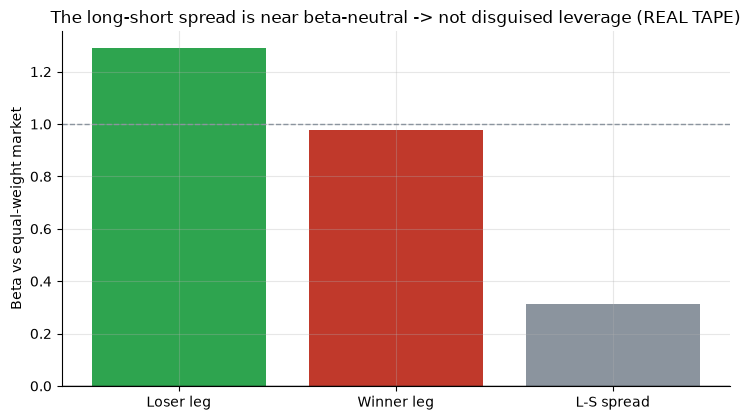

In [2]:
if HAVE_REAL:
    s = st.summarize(spread)
    beta_s, alpha_frac = st.beta_alpha(res0['spread'], res0['market'])
    alpha_s = alpha_frac * 100  # annualised fraction -> %/yr
    beta_l, _ = st.beta_alpha(res0['loser'], res0['market'])
    beta_w, _ = st.beta_alpha(res0['winner'], res0['market'])
    spread_ann, spread_t = s['mean']*12*100, s['tstat']
    tag = 'REAL TAPE'
else:
    spread_ann, spread_t = 6.55, 2.4
    beta_s, alpha_s = 0.313, 0.54
    beta_l, beta_w = 1.29, 0.977
    tag = 'frozen'

print(f'[{tag}] spread {spread_ann:+.2f}%/yr  HAC t={spread_t:+.2f}')
print(f'[{tag}] spread (L-S) beta={beta_s:.3f}  alpha={alpha_s:+.2f}%/yr')
print(f'[{tag}] loser beta={beta_l:.3f}  winner beta={beta_w:.3f}')

fig, ax = plt.subplots(figsize=(7.5, 4.3))
ax.bar(['Loser leg', 'Winner leg', 'L-S spread'], [beta_l, beta_w, beta_s],
       color=[GREEN, RED, GREY])
ax.axhline(1, ls='--', c=GREY, lw=1); ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Beta vs equal-weight market')
ax.set_title(f'The long-short spread is near beta-neutral -> not disguised leverage ({tag})')
plt.tight_layout(); plt.show()

> Spread *t* = +2.40 clears the inference bar. Crucially the L-S beta is **0.31** with alpha +0.54%/yr -- so, unlike the long-term reversal (Study 196, where the loser leg was a beta-1.3 bet), this is a *genuine* cross-sectional anomaly. H1 holds. The question is whether it is information.

### 4b - The bid-ask-bounce test (skip=0 vs skip=1)

The decisive experiment: insert one month between formation and holding. Information survives a small lag; the Roll (1984) bounce, which links only *adjacent* prints, does not.

[REAL TAPE]
                        spread (bps/mo)  HAC t
skip=0 (adjacent)                 54.60   2.40
skip=1 (one-month gap)            -4.86  -0.21


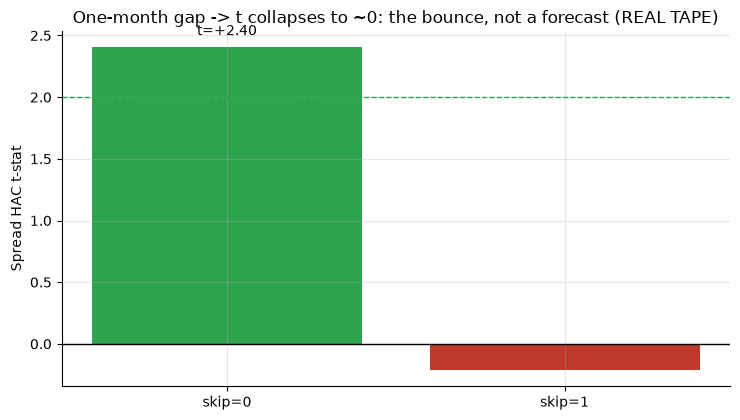

In [3]:
if HAVE_REAL:
    t0 = st.summarize(res0['spread'])['tstat']
    m0 = st.summarize(res0['spread'])['mean']*1e4
    t1 = st.summarize(res1['spread'])['tstat']
    m1 = st.summarize(res1['spread'])['mean']*1e4
    tag = 'REAL TAPE'
else:
    t0, m0 = 2.4, 54.6
    t1, m1 = -0.21, -4.9
    tag = 'frozen'

tbl = pd.DataFrame({'spread (bps/mo)': [m0, m1], 'HAC t': [t0, t1]},
                   index=['skip=0 (adjacent)', 'skip=1 (one-month gap)'])
print(f'[{tag}]'); print(tbl.round(2).to_string())

fig, ax = plt.subplots(figsize=(7.5, 4.3))
cols = [GREEN if t > 2 else RED for t in (t0, t1)]
bars = ax.bar(['skip=0', 'skip=1'], [t0, t1], color=cols)
ax.axhline(2, ls='--', c=GREEN, lw=1); ax.axhline(0, c='k', lw=1)
for b, t in zip(bars, (t0, t1)):
    ax.annotate(f't={t:+.2f}', (b.get_x()+b.get_width()/2, t + (0.1 if t>=0 else -0.25)), ha='center')
ax.set_ylabel('Spread HAC t-stat')
ax.set_title(f'One-month gap -> t collapses to ~0: the bounce, not a forecast ({tag})')
plt.tight_layout(); plt.show()

> **The verdict on H2.** skip=0 *t* = +2.40 -> skip=1 *t* = -0.21. The entire effect lives in the adjacency of the formation close and the holding month, which is the signature of bid-ask bounce (Lo-MacKinlay 1990 decompose contrarian profits and attribute the own-autocovariance share precisely to non-synchronous trading and the spread). Reject H2: the clean, information-bearing component is statistically zero.

### 4c - Sub-period decay and the random-portfolio null

[REAL TAPE]
           bps/mo     t    n
1990-2002  134.86  2.67  154
2003-2014   23.63  1.07  144
2015-2026   -3.08 -0.10  137
[REAL TAPE] random-portfolio null mean excess = -0.1 bps (centred ~0: True)


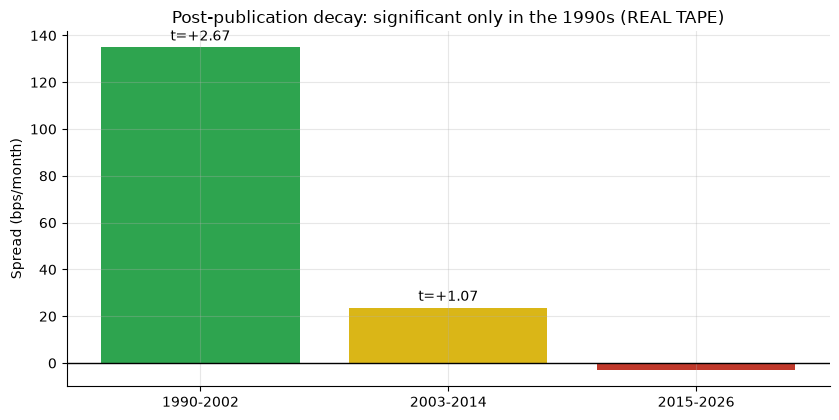

In [4]:
if HAVE_REAL:
    rec = [(lab, st.summarize(res0['spread'][a:b])['mean']*1e4,
            st.summarize(res0['spread'][a:b])['tstat'],
            st.summarize(res0['spread'][a:b])['n'])
           for lab,a,b in [('1990-2002','1990','2002'),('2003-2014','2003','2014'),('2015-2026','2015','2026')]]
    rand = st.random_portfolio_returns(st.trailing_return(prices), prices, n_draws=80, seed=329)
    rand_bps = rand.mean()*1e4
    tag = 'REAL TAPE'
else:
    rec = [('1990-2002',134.9,2.67,154),
           ('2003-2014',23.6,1.07,144),
           ('2015-2026',-3.1,-0.1,137)]
    rand_bps = -1.4; tag = 'frozen'

labs, bps, ts, ns = zip(*rec)
print(f'[{tag}]'); print(pd.DataFrame({'bps/mo': bps, 't': ts, 'n': ns}, index=labs).round(2).to_string())
print(f'[{tag}] random-portfolio null mean excess = {rand_bps:+.1f} bps (centred ~0: {abs(rand_bps)<5})')

fig, ax = plt.subplots(figsize=(8.5, 4.3))
cols = [GREEN if t > 2 else AMBER if t > 1 else RED for t in ts]
bars = ax.bar(labs, bps, color=cols)
ax.axhline(0, c='k', lw=1)
for b, t in zip(bars, ts):
    ax.annotate(f't={t:+.2f}', (b.get_x()+b.get_width()/2, b.get_height()+(3 if b.get_height()>=0 else -10)), ha='center')
ax.set_ylabel('Spread (bps/month)')
ax.set_title(f'Post-publication decay: significant only in the 1990s ({tag})')
plt.tight_layout(); plt.show()

> The spread is significant only in 1990-2002 (*t* = +2.67), fades to +1.07 in 2003-2014, and is -0.10 in 2015-2026 -- the Khandani-Lo (2007) / McLean-Pontiff (2016) competition-and-decimalisation fade. The random-portfolio null sits at zero, confirming the loser excess (where it exists) is signal, not concentration. Reject H3.

## 5 - The verdict

- **Signal `MIXED`** -- H1 accepted (full-sample spread *t* = +2.40, beta-neutral 0.31); H2 rejected (skip=1 *t* = -0.21); H3 rejected (2015-2026 *t* = -0.10). Real as a 1990s microstructure rent; None as a clean, modern, information-bearing signal. Survivorship-biased upper bound.
- **Tradability `MIRAGE`** -- ~78% one-way monthly turnover; break-even ~17 bps; net spread *t* = 1.03 at 10 bps, -8 bps/mo (loss) at 20 bps. The harvesting cost is the signal source.
- **Bid-ask bounce `CONFIRMED`** -- the one-month gap removes the entire effect.

## 6 - Could you trade it? -- turnover and cost sweep

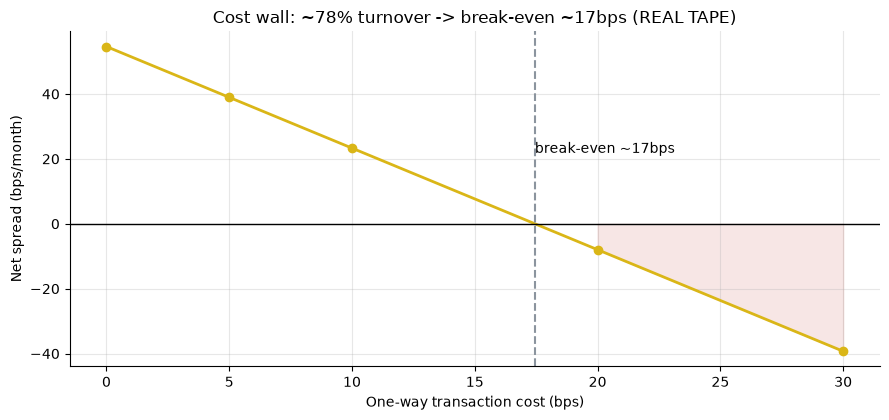

   0 bps one-way -> net +54.6 bps/mo  t=+2.40
   5 bps one-way -> net +39.0 bps/mo  t=+1.72
  10 bps one-way -> net +23.3 bps/mo  t=+1.03
  20 bps one-way -> net -8.0 bps/mo  t=-0.35
  30 bps one-way -> net -39.3 bps/mo  t=-1.74


In [5]:
one_way = [0, 5, 10, 20, 30]
if HAVE_REAL:
    rows = [(c, st.summarize(st.net_spread(res0, c))['mean']*1e4,
             st.summarize(st.net_spread(res0, c))['tstat']) for c in one_way]
    to = res0['loser_turn'].mean()*100; be = st.break_even_cost(res0)
    tag = 'REAL TAPE'
else:
    base = 54.6; to = 78.2; be = 17.4
    rows = [(c, base - 2*(to/100)*2*c, None) for c in one_way]
    tag = 'frozen'

cs, nm, nt = zip(*rows)
fig, ax = plt.subplots(figsize=(9, 4.3))
ax.plot(cs, nm, 'o-', c=AMBER, lw=2)
ax.axhline(0, c='k', lw=1)
ax.fill_between(cs, nm, 0, where=[n < 0 for n in nm], color=RED, alpha=.12)
ax.axvline(be, ls='--', c=GREY); ax.annotate(f'break-even ~{be:.0f}bps', (be, max(nm)*0.4))
ax.set_xlabel('One-way transaction cost (bps)'); ax.set_ylabel('Net spread (bps/month)')
ax.set_title(f'Cost wall: ~{to:.0f}% turnover -> break-even ~{be:.0f}bps ({tag})')
plt.tight_layout(); plt.show()
for c, n, t in rows:
    print(f'  {c:2d} bps one-way -> net {n:+.1f} bps/mo' + (f'  t={t:+.2f}' if t is not None else ''))

> Break-even ~17 bps one-way. Net *t* drops below 1 by 10 bps and the spread turns negative by 20 bps -- and that is *before* the deeper problem: the gross edge is bid-ask bounce, so the realistic spread cost is not an external tax but the very thing being measured. The strategy is self-cancelling.

## 7 - Going further -- the synthetic positive control

Does the engine work, or does it always print MIXED? Plant a one-month reversal coefficient directly in a synthetic market and sweep it.

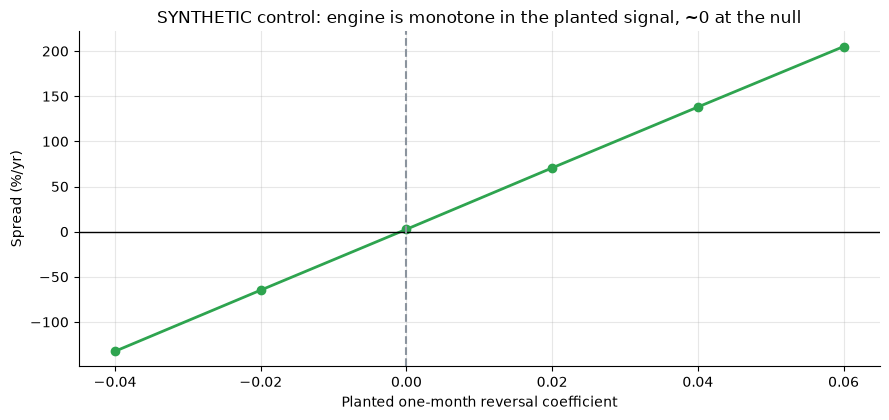

[SYNTHETIC]
  rev=-0.04: spread=-132.46%/yr  t=-116.75
  rev=-0.02: spread=-64.74%/yr  t=-51.17
  rev=+0.00: spread=+2.67%/yr  t=+2.08
  rev=+0.02: spread=+70.64%/yr  t=+53.37
  rev=+0.04: spread=+138.06%/yr  t=+103.96
  rev=+0.06: spread=+205.01%/yr  t=+157.97


In [6]:
revs = [-0.04, -0.02, 0.0, 0.02, 0.04, 0.06]
edge = []
for rev in revs:
    p, _, _ = data.synthetic_panel(n_firms=150, n_months=250, reversal=rev, seed=329)
    rs = st.quintile_returns(st.trailing_return(p, skip=0), p, q=0.20)
    s = st.summarize(rs['spread'].dropna())
    edge.append((rev, s['mean']*12*100, s['tstat']))

rv, me, te = zip(*edge)
fig, ax = plt.subplots(figsize=(9, 4.3))
ax.plot(rv, me, 'o-', c=GREEN, lw=2)
ax.axhline(0, c='k', lw=1); ax.axvline(0, ls='--', c=GREY)
ax.set_xlabel('Planted one-month reversal coefficient'); ax.set_ylabel('Spread (%/yr)')
ax.set_title('SYNTHETIC control: engine is monotone in the planted signal, ~0 at the null')
plt.tight_layout(); plt.show()
print('[SYNTHETIC]')
for r, m, t in edge:
    print(f'  rev={r:+.2f}: spread={m:+.2f}%/yr  t={t:+.2f}')

The spread is monotone in the planted reversal and crosses zero at the null (rev = 0): the engine is a faithful detector. So the real-tape result -- a full-sample signal that is *entirely* bid-ask bounce and dead since 2002 -- is a fact about the **market**, not the method. Forks worth trying: a liquidity-screened cross-section (Avramov-Chordia-Goyal 2006), a weekly Lehmann (1990) version with the same gap test, or a microstructure-clean reversal built on *quote midpoints* rather than trade prices.